In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
includet("./base.jl")

┌ Warning: Circular dependency detected.
│ Precompilation will be skipped for dependencies in this cycle:
│  ┌ Symbolics → SymbolicsForwardDiffExt
│  └─ Symbolics → SymbolicsPreallocationToolsExt
│ Precompilation will also be skipped for the following, which depend on the above cycle:
│   SSMC
│   MLSolver
└ @ Pkg.API.Precompilation ~/.julia/juliaup/julia-1.10.10+0.x64.linux.gnu/share/julia/stdlib/v1.10/Pkg/src/precompilation.jl:583
Precompiling packages...
  12657.5 ms  ✓ SSMCMain
  1 dependency successfully precompiled in 16 seconds. 540 already precompiled. 4 skipped due to circular dependency.


In [3]:
using CairoMakie
using GLMakie
CairoMakie.activate!()

# Testing v1

In [12]:
Klis_to_run = [
    (9.319395762340777, 1.0),
    (26.826957952797258, 1.0),
    (77.22449945836259, 1.0),
    (222.29964825261956, 1.0),
    (517.9474679231213, 1.0)
]
num_runs = 8
N = 5

DN = 1e-12

T = 1000000000
L = 15
sN = 2000

sp_epsilon = 1e-3

run_v1_odesonly(
    "data_test3.jld2",
    Klis_to_run, num_runs, N, N, DN,
    T, L, sN, sp_epsilon;
    # ode_u0=[fill(10000.0, N); fill(0.0, M)],
)

Starting ODE runs


Progress:   5%|██                                       |  ETA: 0:02:44┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:626
Progress: 100%|█████████████████████████████████████████| Time: 0:00:23


(metadata = (Klis_to_run = [(9.319395762340777, 1.0), (26.826957952797258, 1.0), (77.22449945836259, 1.0), (222.29964825261956, 1.0), (517.9474679231213, 1.0)], N = 5, M = 5, DN = 1.0e-12, T = 1000000000, ode_u0 = [1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0], lsks = [1.0e-5, 1.008095673533814e-5, 1.0162568869975964e-5, 1.024484170981219e-5, 1.0327780603700453e-5, 1.0411390943796867e-5, 1.0495678165910756e-5, 1.058064774985797e-5, 1.0666305219817105e-5, 1.0752656144688783e-5  …  93.00027700541183, 93.75317688660202, 94.51217199943396, 95.27731168891312, 96.0486456995261, 96.82622417847453, 97.6100976789354, 98.40031716334786, 99.19693400672615, 100.0], L = 15, sN = 2000, sp_epsilon = 0.001, num_runs = 8, pde_solve_maxtime = 7200, run_threads = 8), params = BSMMiCRMParams[BSMMiCRMParams{Nothing, Nothing, Nothing, Float64}(BMMiCRMParams{Nothing, Float64}([1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0], [0.9937870968582894, 0.9982709561484515, 1.002242287581978, 0.99966463156979

In [176]:
close(f)
empty!(Out)
GC.gc()

# Testing v1

In [13]:
f = jldopen("./data_test3.jld2")

@show countmap(f["ode_retcodes"])
@show countmap(f["sp_retcodes"]);

fmetadata = f["metadata"]
Klis = fmetadata.Klis_to_run

N = fmetadata.N
M = fmetadata.M
dx = fmetadata.L / fmetadata.sN

fparams = f["params"]
fode_fss = f["ode_final_states"]
fsp_fss = f["sp_final_states"]

f

countmap(f["ode_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.Success => 39, SciMLBase.ReturnCode.MaxIters => 1)
countmap(f["sp_retcodes"]) = Dict{SciMLBase.ReturnCode.T, Int64}(SciMLBase.ReturnCode.<invalid #981513448> => 2, SciMLBase.ReturnCode.Success => 6, SciMLBase.ReturnCode.<invalid #1053125320> => 2, SciMLBase.ReturnCode.<invalid #100> => 1, SciMLBase.ReturnCode.Failure => 1, SciMLBase.ReturnCode.<invalid #256> => 1, SciMLBase.ReturnCode.Default => 17, SciMLBase.ReturnCode.MaxNumSub => 4, SciMLBase.ReturnCode.<invalid #32603> => 5, SciMLBase.ReturnCode.<invalid #642646272> => 1)


JLDFile /home/honza/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode/cluster_env/runs/single_influx_pdes3/data_test3.jld2 (read-only)
 ├─🔢 metadata
 ├─🔢 params
 ├─🔢 ode_retcodes
 ├─🔢 ode_final_states
 ├─🔢 ode_final_Ts
 ├─🔢 linstab_mrls
 ├─🔢 sp_retcodes
 ├─🔢 sp_final_states
 └─🔢 sp_final_Ts

In [14]:
map(fode_fss) do x maximum(x[1:N]) end

8×5 Matrix{Float64}:
 6.72567  19.1478  75.061     6.74117e-33  333.815
 7.1887   23.9057  42.723   219.786        513.606
 7.20809  13.9728  74.9019  175.272        515.223
 4.15985  24.7354  55.7003  220.602        512.997
 7.19973  23.9099  39.2832  219.67         426.356
 7.19472  18.9353  49.6991  220.049        517.547
 5.9207   24.8069  75.4143  135.547        404.285
 7.09175  17.0885  58.6027  220.313        216.108

In [20]:
group_i = 1
run_i = 7

ps = fparams[run_i, group_i]
ode_fss = fode_fss[run_i, group_i]
# sp_fss = fsp_fss[run_i, group_i];

maximum(ode_fss[1:N])

5.920695453058151

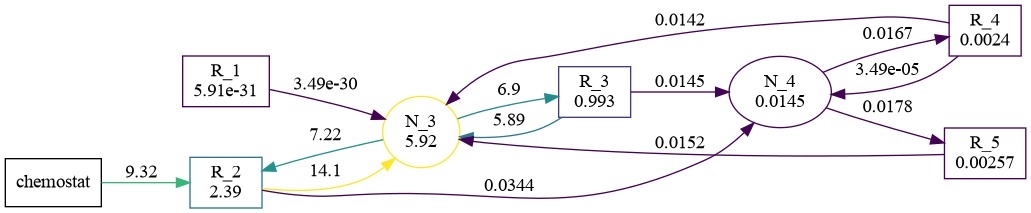

In [21]:
diagram_sfss_v3(ps, ode_fss;
    strain_threshold=0.01
)

In [23]:
plot_spatial_fs(sp_fss, 20, fmetadata.sN, dx)

LoadError: UndefVarError: `sp_fss` not defined